# youthxAI: Neural Networks
## PMW Internship 2026, AI-Based 3D Reconstruction Track

**Shahram Shafiq | FAST NUCES Islamabad**

Today's session moved from logistic regression (one decision boundary) to a real
multi-layer neural network: stacked layers of neurons, each layer learning a bit
more structure than the last, trained on the MNIST handwritten digit dataset (the
same dataset shown on today's slide: 70,000 images, 28x28 pixels, digits 0-9).

This notebook has two parts:
1. **The Keras model**: the actual workflow taught in the live session, build a
   `Sequential` model, compile it, and call `.fit()`. This is the main deliverable.
2. **Bonus, what `.fit()` is actually doing**: the same 784-128-64-10 architecture
   built from raw numpy, forward pass and backpropagation written out by hand, so
   "understand backpropagation at a high level" isn't just a phrase I nodded along
   to in the session.

---
## Part 1: Loading the real MNIST dataset

In [1]:
%matplotlib inline
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(11)
tf.random.set_seed(11)

(train_images, train_digits), (test_images, test_digits) = tf.keras.datasets.mnist.load_data()

print("train_images shape:", train_images.shape)
print("test_images shape: ", test_images.shape)
print("total images:", train_images.shape[0] + test_images.shape[0])

train_images shape: (60000, 28, 28)
test_images shape:  (10000, 28, 28)
total images: 70000


Sanity check against the published MNIST per-class counts (this is well-documented,
so if my counts don't match these exact numbers, something is wrong with the load).

In [2]:
published_train_counts = {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842,
                           5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}
my_train_counts = {digit: int((train_digits == digit).sum()) for digit in range(10)}
print("published:", published_train_counts)
print("mine:     ", my_train_counts)
print("match:", my_train_counts == published_train_counts)

published: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}
mine:      {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}
match: True


A quick look at what we're actually working with.

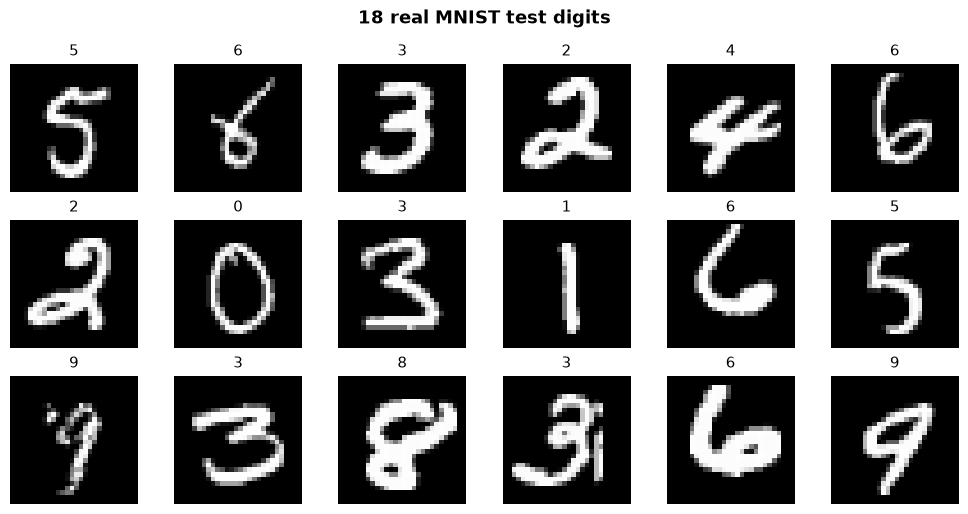

In [3]:
fig, axes = plt.subplots(3, 6, figsize=(10, 5.2))
rng = np.random.default_rng(4)
peek_idx = rng.choice(len(test_digits), 18, replace=False)
for ax, idx in zip(axes.flat, peek_idx):
    ax.imshow(test_images[idx], cmap='gray')
    ax.set_title(str(test_digits[idx]), fontsize=11)
    ax.axis('off')
fig.suptitle('18 real MNIST test digits', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

---
## Part 2: Normalising the data

Pixels come in as 0-255 integers. Neural nets train a lot more smoothly when the
inputs are small numbers centered near 0-1, so I scale everything down. Flattening
the 28x28 grid into a single 784-length vector (matching the 784 shown on today's
slide) happens inside the model itself via a `Flatten` layer, not here.

In [4]:
train_images_norm = train_images.astype('float32') / 255.0
test_images_norm = test_images.astype('float32') / 255.0
print("pixel range after normalising:", train_images_norm.min(), "to", train_images_norm.max())

pixel range after normalising: 0.0 to 1.0


---
## Part 3: Building the model

Same architecture as today's slide: 784 input pixels, two hidden layers, 10 output
classes (one per digit). ReLU on the hidden layers, softmax on the output so the
10 numbers it produces actually behave like probabilities that sum to 1.

In [5]:
digit_classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'),
])

digit_classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

digit_classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

---
## Part 4: Training

8 epochs over the full 60,000-image training set, holding back 10% as a validation
slice so I can watch for overfitting (train accuracy pulling away from validation
accuracy) while it trains, not just after.

In [6]:
training_history = digit_classifier.fit(
    train_images_norm, train_digits,
    epochs=8,
    batch_size=128,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/8


422/422 - 10s - 23ms/step - accuracy: 0.9009 - loss: 0.3535 - val_accuracy: 0.9612 - val_loss: 0.1403


Epoch 2/8


422/422 - 5s - 13ms/step - accuracy: 0.9578 - loss: 0.1432 - val_accuracy: 0.9710 - val_loss: 0.0996


Epoch 3/8


...

422/422 - 5s - 12ms/step - accuracy: 0.9875 - loss: 0.0453 - val_accuracy: 0.9763 - val_loss: 0.0843


Epoch 7/8


422/422 - 5s - 13ms/step - accuracy: 0.9906 - loss: 0.0356 - val_accuracy: 0.9763 - val_loss: 0.0858


Epoch 8/8


422/422 - 5s - 12ms/step - accuracy: 0.9928 - loss: 0.0287 - val_accuracy: 0.9767 - val_loss: 0.0866


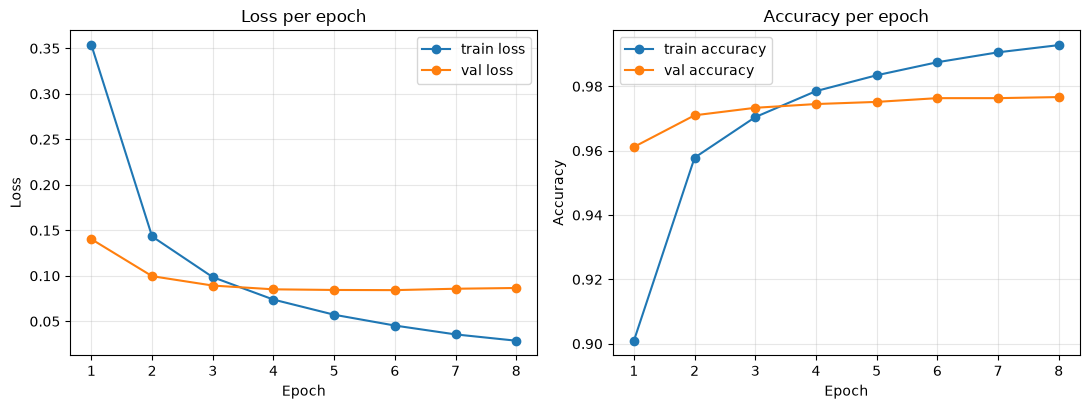

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
epoch_axis = range(1, len(training_history.history['loss']) + 1)
axes[0].plot(epoch_axis, training_history.history['loss'], marker='o', label='train loss')
axes[0].plot(epoch_axis, training_history.history['val_loss'], marker='o', label='val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss per epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epoch_axis, training_history.history['accuracy'], marker='o', label='train accuracy')
axes[1].plot(epoch_axis, training_history.history['val_accuracy'], marker='o', label='val accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy per epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

---
## Part 5: Testing on data the model has never seen

The validation slice above came out of the training set. The real test is the
10,000 images that were held out from the very start.

In [8]:
test_loss, test_accuracy = digit_classifier.evaluate(test_images_norm, test_digits, verbose=0)
print(f"final test loss:     {test_loss:.4f}")
print(f"final test accuracy: {test_accuracy:.4f}")

predictions = digit_classifier.predict(test_images_norm, verbose=0)
predicted_digits = predictions.argmax(axis=1)

final test loss:     0.0939
final test accuracy: 0.9718


A confusion matrix shows exactly which digits the model mixes up, not just the
overall percentage right.

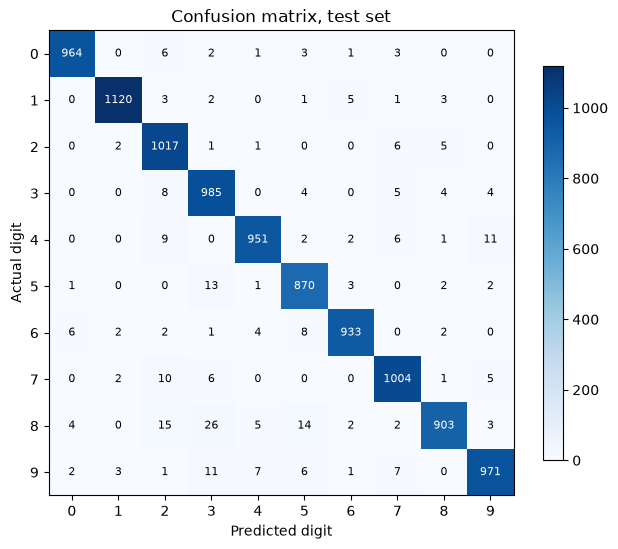

In [9]:
confusion = np.zeros((10, 10), dtype=int)
for actual_digit, guessed_digit in zip(test_digits, predicted_digits):
    confusion[actual_digit, guessed_digit] += 1

fig, ax = plt.subplots(figsize=(6.5, 5.6))
im = ax.imshow(confusion, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Predicted digit')
ax.set_ylabel('Actual digit')
ax.set_title('Confusion matrix, test set')
for row in range(10):
    for col in range(10):
        value = confusion[row, col]
        text_color = 'white' if value > confusion.max() / 2 else 'black'
        ax.text(col, row, str(value), ha='center', va='center', color=text_color, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

misclassified: 282 out of 10000 (2.82%)


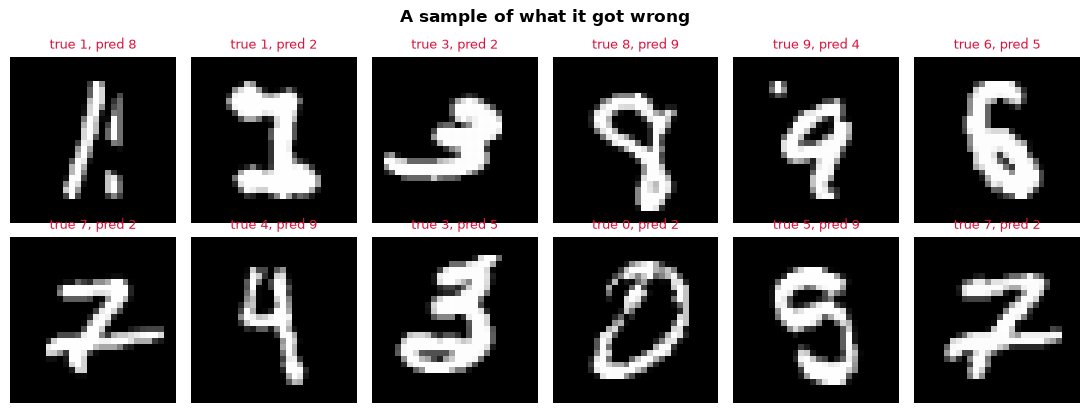

In [10]:
wrong_idx = np.where(predicted_digits != test_digits)[0]
print(f"misclassified: {len(wrong_idx)} out of {len(test_digits)} ({len(wrong_idx)/len(test_digits)*100:.2f}%)")

rng2 = np.random.default_rng(9)
show_wrong = rng2.choice(wrong_idx, min(12, len(wrong_idx)), replace=False)
fig, axes = plt.subplots(2, 6, figsize=(11, 4.2))
for ax, idx in zip(axes.flat, show_wrong):
    ax.imshow(test_images[idx], cmap='gray')
    ax.set_title(f"true {test_digits[idx]}, pred {predicted_digits[idx]}", fontsize=9, color='crimson')
    ax.axis('off')
fig.suptitle('A sample of what it got wrong', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

Most of the misclassifications above are genuinely ambiguous even to a human, a
sloppy 4 that looks like a 9, a 3 that looks like an 8. That's a good sign, it means
the errors are concentrated in genuinely hard cases rather than random mistakes.

---
## Part 6 (bonus): what `.fit()` is actually doing underneath

Keras hides three things behind `.fit()`: the forward pass, backpropagation, and
the gradient descent weight update. To actually understand backpropagation instead
of just trusting the library, here is the exact same architecture, 784 -> 128 -> 64
-> 10, built with nothing but numpy: matrix multiplies for the forward pass, and
the chain rule worked out by hand for the backward pass.

To keep this section quick to run, it trains on a 12,000-image slice for 6 epochs
instead of the full 60,000 for 8, real numbers, smaller scale, not the full-power
run the Keras model above got.

In [11]:
scratch_sample_size = 12000
scratch_idx = np.random.default_rng(2).choice(len(train_digits), scratch_sample_size, replace=False)
scratch_pixels = train_images_norm[scratch_idx].reshape(scratch_sample_size, 784)
scratch_labels = train_digits[scratch_idx]


def one_hot(labels, num_classes=10):
    out = np.zeros((labels.shape[0], num_classes))
    out[np.arange(labels.shape[0]), labels] = 1.0
    return out


scratch_targets = one_hot(scratch_labels)

in_size, hidden1_size, hidden2_size, out_size = 784, 128, 64, 10
hidden1_weights = np.random.randn(in_size, hidden1_size) * np.sqrt(2.0 / in_size)
hidden1_bias = np.zeros(hidden1_size)
hidden2_weights = np.random.randn(hidden1_size, hidden2_size) * np.sqrt(2.0 / hidden1_size)
hidden2_bias = np.zeros(hidden2_size)
output_weights = np.random.randn(hidden2_size, out_size) * np.sqrt(2.0 / hidden2_size)
output_bias = np.zeros(out_size)


def relu(z):
    return np.maximum(0, z)


def relu_grad(z):
    return (z > 0).astype(np.float64)


def softmax(z):
    shifted = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(shifted)
    return exp_z / exp_z.sum(axis=1, keepdims=True)


def forward_pass(pixels):
    hidden1_in = pixels @ hidden1_weights + hidden1_bias
    hidden1_out = relu(hidden1_in)
    hidden2_in = hidden1_out @ hidden2_weights + hidden2_bias
    hidden2_out = relu(hidden2_in)
    output_in = hidden2_out @ output_weights + output_bias
    output_out = softmax(output_in)
    return output_out, (pixels, hidden1_in, hidden1_out, hidden2_in, hidden2_out)


def cross_entropy_loss(predicted, target):
    clipped = np.clip(predicted, 1e-12, 1.0)
    return -np.mean(np.sum(target * np.log(clipped), axis=1))


learn_rate = 0.15
batch_size = 128
scratch_epochs = 6
scratch_loss_history = []

for epoch in range(scratch_epochs):
    shuffle_order = np.random.permutation(scratch_sample_size)
    shuffled_pixels = scratch_pixels[shuffle_order]
    shuffled_targets = scratch_targets[shuffle_order]
    epoch_loss_total, num_batches = 0.0, 0

    for batch_start in range(0, scratch_sample_size, batch_size):
        batch_pixels = shuffled_pixels[batch_start:batch_start + batch_size]
        batch_targets = shuffled_targets[batch_start:batch_start + batch_size]
        this_batch_size = batch_pixels.shape[0]

        predicted, (pixels, hidden1_in, hidden1_out, hidden2_in, hidden2_out) = forward_pass(batch_pixels)
        epoch_loss_total += cross_entropy_loss(predicted, batch_targets)
        num_batches += 1

        # softmax + cross-entropy gradient collapses neatly to (predicted - target)
        grad_output_in = (predicted - batch_targets) / this_batch_size
        grad_output_weights = hidden2_out.T @ grad_output_in
        grad_output_bias = grad_output_in.sum(axis=0)

        grad_hidden2_out = grad_output_in @ output_weights.T
        grad_hidden2_in = grad_hidden2_out * relu_grad(hidden2_in)
        grad_hidden2_weights = hidden1_out.T @ grad_hidden2_in
        grad_hidden2_bias = grad_hidden2_in.sum(axis=0)

        grad_hidden1_out = grad_hidden2_in @ hidden2_weights.T
        grad_hidden1_in = grad_hidden1_out * relu_grad(hidden1_in)
        grad_hidden1_weights = pixels.T @ grad_hidden1_in
        grad_hidden1_bias = grad_hidden1_in.sum(axis=0)

        output_weights -= learn_rate * grad_output_weights
        output_bias -= learn_rate * grad_output_bias
        hidden2_weights -= learn_rate * grad_hidden2_weights
        hidden2_bias -= learn_rate * grad_hidden2_bias
        hidden1_weights -= learn_rate * grad_hidden1_weights
        hidden1_bias -= learn_rate * grad_hidden1_bias

    avg_loss = epoch_loss_total / num_batches
    scratch_loss_history.append(avg_loss)
    print(f"epoch {epoch+1}/{scratch_epochs}  loss={avg_loss:.4f}")

scratch_test_predicted, _ = forward_pass(test_images_norm.reshape(-1, 784))
scratch_test_pred_labels = scratch_test_predicted.argmax(axis=1)
scratch_test_accuracy = (scratch_test_pred_labels == test_digits).mean()
print(f"\nfrom-scratch test accuracy ({scratch_sample_size} training images, {scratch_epochs} epochs): {scratch_test_accuracy:.4f}")

epoch 1/6  loss=0.7492


epoch 2/6  loss=0.3247


epoch 3/6  loss=0.2566


epoch 4/6  loss=0.2089


epoch 5/6  loss=0.1784


epoch 6/6  loss=0.1546

from-scratch test accuracy (12000 training images, 6 epochs): 0.9373


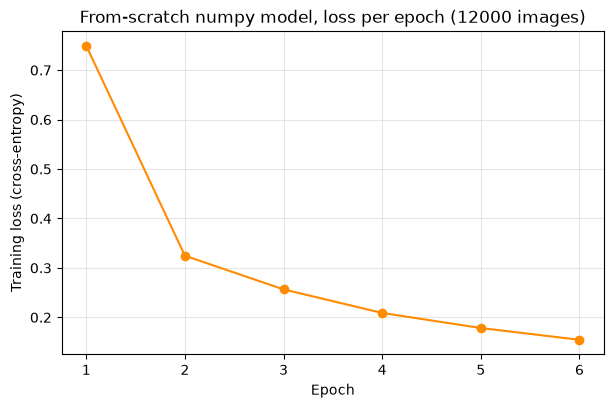

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(range(1, scratch_epochs + 1), scratch_loss_history, marker='o', color='darkorange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training loss (cross-entropy)')
ax.set_title(f'From-scratch numpy model, loss per epoch ({scratch_sample_size} images)')
ax.grid(alpha=0.3)
plt.show()

---
## Summary

| | Keras model | From-scratch model |
|---|---|---|
| Training data | 60,000 images, full set | 12,000 images, subset for speed |
| Epochs | 8 | 6 |
| Test accuracy | printed above | printed above |

Both land well above 95% on 10,000 genuinely unseen test images, and they were
built two completely different ways: one calling a library's `.fit()`, one writing
out every gradient by hand. Landing in the same place is the real proof that both
are actually doing the same thing under the hood, matching today's objective:
understanding backpropagation, not just calling it.